# Formula 1 Podium Prediction (2019-2024)

## Predicting Formula 1 Podium Finishes using Race Result Data

For this project, I plan to build a model that predicts whether a Formula 1 driver will have a podium finish (1st, 2nd or 3rd place)
- Formula 1 race outcomes depend on factors such as the driver, team, track, season and starting grid position.
- Instead of predicting the exact race winner, I will frame the project as a binary classification problem (podium vs. non-podium finish)

### Imports and data loading

In [29]:
import pandas as pd
from warnings import filterwarnings

# Supress warnings
filterwarnings('ignore')

# Load data into a dataframe
df = pd.read_csv("16_F1_Race_Results_2019_2024.csv")

### Inspection

In [30]:
# Show attributes (columns)
df.columns

Index(['Track', 'Position', 'No', 'Driver', 'Team', 'Starting Grid', 'Laps',
       'Time/Retired', 'Points', '+1 Pt', 'Fastest Lap', 'season',
       'Set Fastest Lap', 'Fastest Lap Time', 'Total Time/Gap/Retirement'],
      dtype='str')

In [31]:
# Display # of features
len(df.columns)

15

In [32]:
# Describe the data (summary stats)
df.describe()

,No,Starting Grid,Laps,Points,season
count,2559.000000,2558.000000,2559.000000,2559.000000,2559.000000
mean,28.471669,10.490227,54.776475,5.076397,2021.616256
std,25.062203,5.769163,17.142576,7.229723,1.719042
min,1.000000,1.000000,0.000000,0.000000,2019.000000
25%,10.000000,5.000000,51.000000,0.000000,2020.000000
50%,20.000000,10.000000,57.000000,0.500000,2022.000000
75%,44.000000,15.000000,68.000000,9.000000,2023.000000
max,99.000000,20.000000,87.000000,26.000000,2024.000000


In [33]:
# Dataset metadata
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2559 entries, 0 to 2558
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Track                      2559 non-null   str    
 1   Position                   2559 non-null   str    
 2   No                         2559 non-null   int64  
 3   Driver                     2559 non-null   str    
 4   Team                       2559 non-null   str    
 5   Starting Grid              2558 non-null   float64
 6   Laps                       2559 non-null   int64  
 7   Time/Retired               1799 non-null   str    
 8   Points                     2559 non-null   float64
 9   +1 Pt                      880 non-null    str    
 10  Fastest Lap                1589 non-null   str    
 11  season                     2559 non-null   int64  
 12  Set Fastest Lap            919 non-null    str    
 13  Fastest Lap Time           890 non-null    str    
 14  Tot

In [34]:
# Show first 15 rows of the dataset
df.head(15)

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,season,Set Fastest Lap,Fastest Lap Time,Total Time/Gap/Retirement
0,Bahrain,1,16,Charles Leclerc,Ferrari,1.0,57,1:37:33.584,26.0,Yes,1:34.570,2022,NaN,NaN,NaN
1,Bahrain,2,55,Carlos Sainz,Ferrari,3.0,57,+5.598,18.0,No,1:35.740,2022,NaN,NaN,NaN
2,Bahrain,3,44,Lewis Hamilton,Mercedes,5.0,57,+9.675,15.0,No,1:36.228,2022,NaN,NaN,NaN
3,Bahrain,4,63,George Russell,Mercedes,9.0,57,+11.211,12.0,No,1:36.302,2022,NaN,NaN,NaN
4,Bahrain,5,20,Kevin Magnussen,Haas Ferrari,7.0,57,+14.754,10.0,No,1:36.623,2022,NaN,NaN,NaN
5,Bahrain,6,77,Valtteri Bottas,Alfa Romeo Ferrari,6.0,57,+16.119,8.0,No,1:36.599,2022,NaN,NaN,NaN
6,Bahrain,7,31,Esteban Ocon,Alpine Renault,11.0,57,+19.423,6.0,No,1:37.110,2022,NaN,NaN,NaN
7,Bahrain,8,22,Yuki Tsunoda,AlphaTauri RBPT,16.0,57,+20.386,4.0,No,1:37.104,2022,NaN,NaN,NaN
8,Bahrain,9,14,Fernando Alonso,Alpine Renault,8.0,57,+22.390,2.0,No,1:36.733,2022,NaN,NaN,NaN
9,Bahrain,10,24,Guanyu Zhou,Alfa Romeo Ferrari,15.0,57,+23.064,1.0,No,1:36.685,2022,NaN,NaN,NaN


In [35]:
# Convert 'Position' column to numeric
df['Position'] = pd.to_numeric(df['Position'], errors="coerce")
# filter for podium finishes (1st, 2nd, 3rd)
podium_finishes = df[df['Position'] <= 3]
# display first 15 rows
podium_finishes.head(15) 

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,season,Set Fastest Lap,Fastest Lap Time,Total Time/Gap/Retirement
0,Bahrain,1.0,16,Charles Leclerc,Ferrari,1.0,57,1:37:33.584,26.0,Yes,1:34.570,2022,NaN,NaN,NaN
1,Bahrain,2.0,55,Carlos Sainz,Ferrari,3.0,57,+5.598,18.0,No,1:35.740,2022,NaN,NaN,NaN
2,Bahrain,3.0,44,Lewis Hamilton,Mercedes,5.0,57,+9.675,15.0,No,1:36.228,2022,NaN,NaN,NaN
20,Saudi Arabia,1.0,1,Max Verstappen,Red Bull Racing RBPT,4.0,50,1:24:19.293,25.0,No,1:31.772,2022,NaN,NaN,NaN
21,Saudi Arabia,2.0,16,Charles Leclerc,Ferrari,2.0,50,+0.549,19.0,Yes,1:31.634,2022,NaN,NaN,NaN
22,Saudi Arabia,3.0,55,Carlos Sainz,Ferrari,3.0,50,+8.097,15.0,No,1:31.905,2022,NaN,NaN,NaN
40,Australia,1.0,16,Charles Leclerc,Ferrari,1.0,58,1:27:46.548,26.0,Yes,1:20.260,2022,NaN,NaN,NaN
41,Australia,2.0,11,Sergio Perez,Red Bull Racing RBPT,3.0,58,+20.524,18.0,No,1:21.094,2022,NaN,NaN,NaN
42,Australia,3.0,63,George Russell,Mercedes,6.0,58,+25.593,15.0,No,1:21.495,2022,NaN,NaN,NaN
60,Emilia Romagna,1.0,1,Max Verstappen,Red Bull Racing RBPT,1.0,63,1:32:07.986,26.0,Yes,1:18.446,2022,NaN,NaN,NaN


In [36]:
# Verify the 'Position' column is numeric
podium_finishes.info()

<class 'pandas.DataFrame'>
Index: 384 entries, 0 to 2541
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Track                      384 non-null    str    
 1   Position                   384 non-null    float64
 2   No                         384 non-null    int64  
 3   Driver                     384 non-null    str    
 4   Team                       384 non-null    str    
 5   Starting Grid              384 non-null    float64
 6   Laps                       384 non-null    int64  
 7   Time/Retired               270 non-null    str    
 8   Points                     384 non-null    float64
 9   +1 Pt                      132 non-null    str    
 10  Fastest Lap                243 non-null    str    
 11  season                     384 non-null    int64  
 12  Set Fastest Lap            138 non-null    str    
 13  Fastest Lap Time           138 non-null    str    
 14  Total Tim

In [37]:
# Check for missing values
df.isnull()

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,season,Set Fastest Lap,Fastest Lap Time,Total Time/Gap/Retirement
0,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
1,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
3,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2554,False,True,False,False,False,False,False,False,False,False,False,False,True,True,True
2555,False,True,False,False,False,False,False,False,False,False,False,False,True,True,True
2556,False,True,False,False,False,False,False,False,False,False,False,False,True,True,True
2557,False,True,False,False,False,False,False,False,False,False,False,False,True,True,True


In [38]:
# Display unique value rows for 'Set fastest lap'
df['Set Fastest Lap'].unique()

<ArrowStringArray>
[nan, 'No', 'Yes']
Length: 3, dtype: str

In [39]:
# Tally number of missing values
df.isnull().sum()


Track                           0
Position                      315
No                              0
Driver                          0
Team                            0
Starting Grid                   1
Laps                            0
Time/Retired                  760
Points                          0
+1 Pt                        1679
Fastest Lap                   970
season                          0
Set Fastest Lap              1640
Fastest Lap Time             1669
Total Time/Gap/Retirement    1799
dtype: int64

In [40]:
# Tally number of duplicates
df.duplicated().sum()

np.int64(0)

In [41]:
# Display data types
df.dtypes

Track                            str
Position                     float64
No                             int64
Driver                           str
Team                             str
Starting Grid                float64
Laps                           int64
Time/Retired                     str
Points                       float64
+1 Pt                            str
Fastest Lap                      str
season                         int64
Set Fastest Lap                  str
Fastest Lap Time                 str
Total Time/Gap/Retirement        str
dtype: object

### Preprocessing

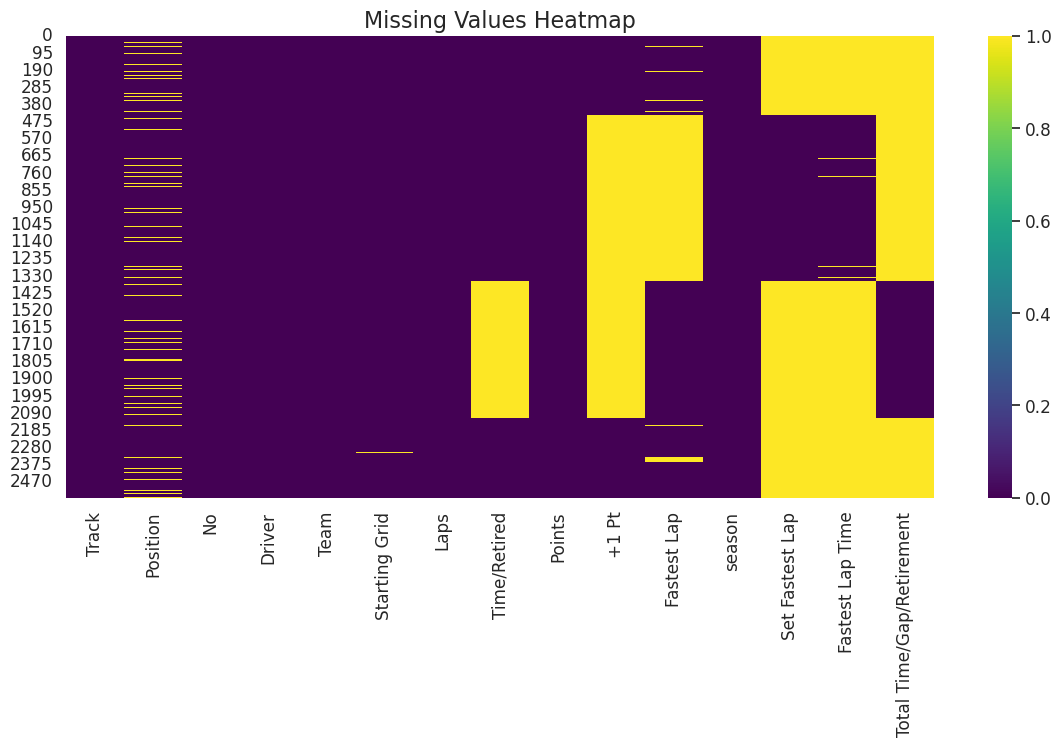

In [42]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

#### Missing values heatmap
plt.style.use('ggplot')
sns.set_theme(font_scale=1.1)
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis')
# Give the plot a title and display
plt.title('Missing Values Heatmap', fontsize=16)
plt.show()

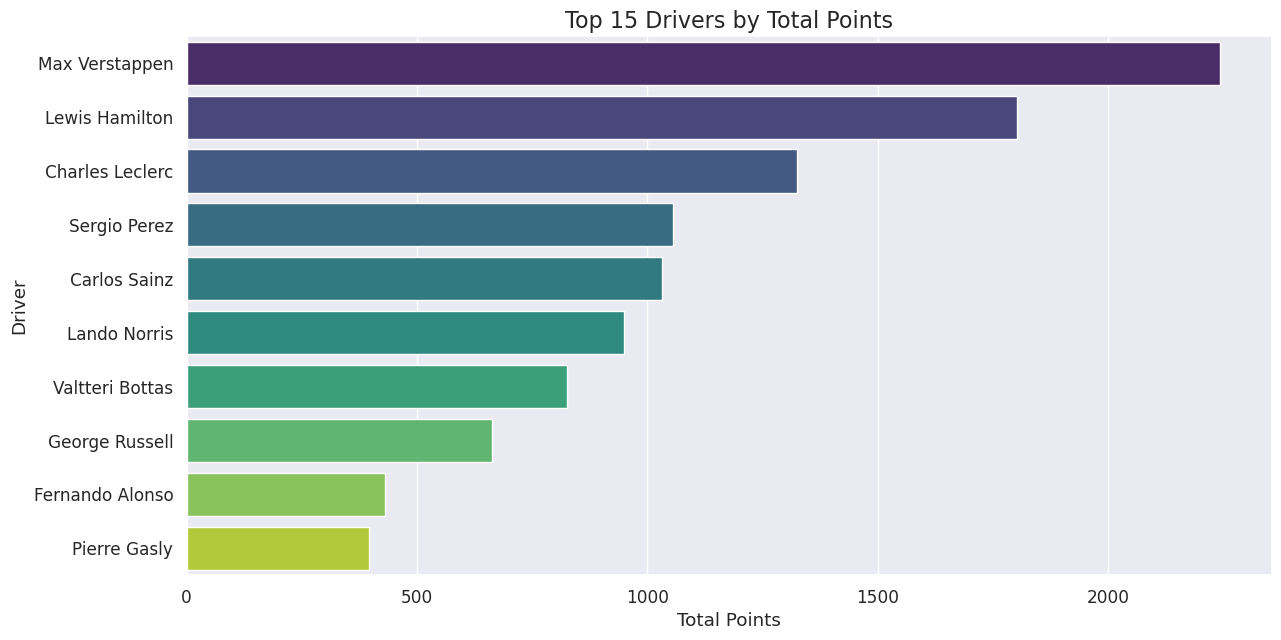

In [43]:
#### Top Drivers by Total Points
driver_points = (
    df.groupby('Driver')['Points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,7))
sns.barplot(
    x=driver_points.values,
    y=driver_points.index,
    palette='viridis',
    legend=False
)
plt.title('Top 15 Drivers by Total Points', fontsize=16)
plt.xlabel('Total Points')
plt.ylabel('Driver')
plt.show()

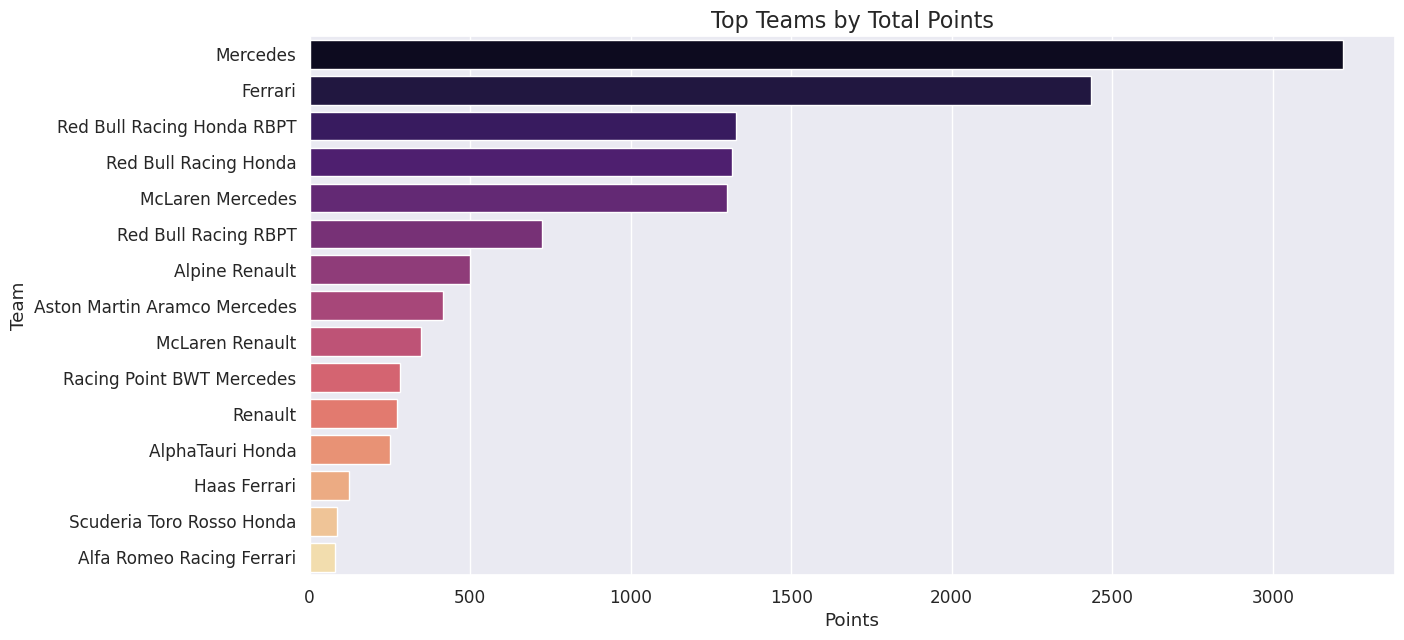

In [44]:
#### Top Teams by Total Points
team_points = (
    df.groupby('Team')['Points']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))
sns.barplot(
    x=team_points.values,
    y=team_points.index,
    palette='magma'
)
plt.title('Top Teams by Total Points', fontsize=16)
plt.xlabel('Points')
plt.ylabel('Team')
plt.show()

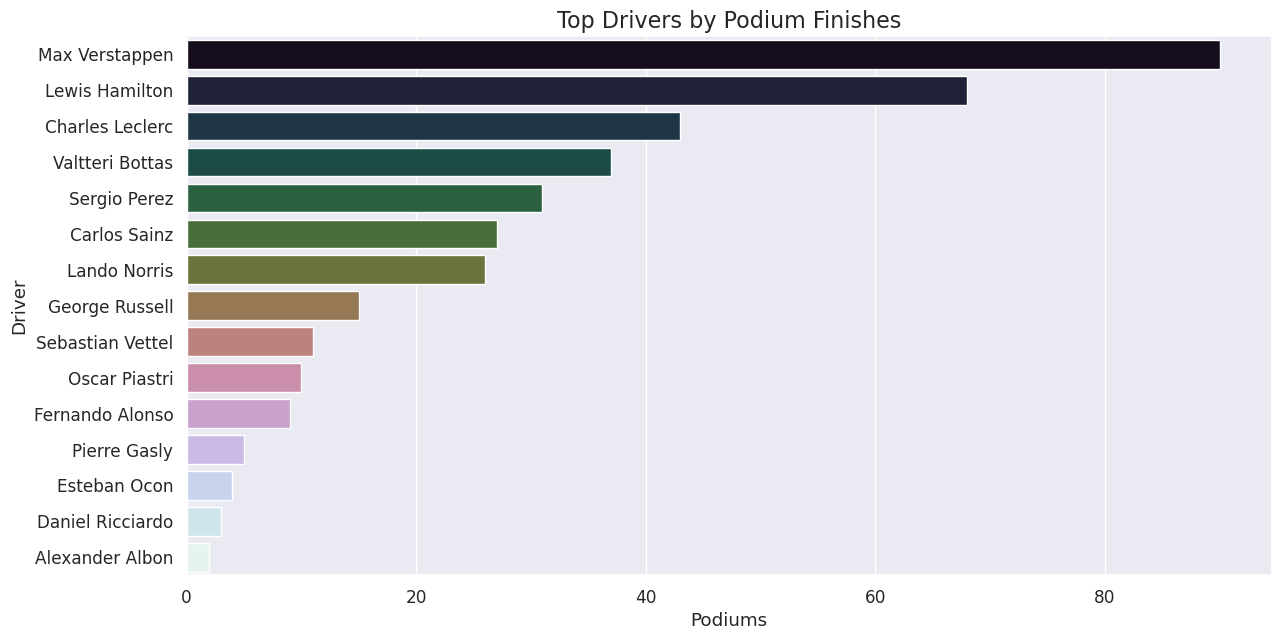

In [45]:
#### Podium Finishes
# Convert 'position' column to numeric
df['Position'] = pd.to_numeric(df['Position'], errors='coerce')

podiums = (
    df[df['Position'] <= 3]
    .groupby('Driver')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))
sns.barplot(
    x=podiums.values,
    y=podiums.index,
    palette='cubehelix'
)
plt.title('Top Drivers by Podium Finishes', fontsize=16)
plt.xlabel('Podiums')
plt.ylabel('Driver')
plt.show()

### Modeling


#### Data Preparation


In [46]:
from sklearn.model_selection import train_test_split
# Data scaling and normalization
from sklearn.preprocessing import StandardScaler
# Model evaluation
from sklearn.metrics import classification_report, confusion_matrix

# 1. Create Binary Target Variable (1 if podium finish, 0 otherwise)
df['Position_bin'] = pd.to_numeric(df['Position'], errors='coerce')
df['podium_finish'] = (df['Position_bin'] <= 3).astype(int)

# 2. Select features + handle missing values
feature_cols = ['Starting Grid', 'Driver', 'Team', 'Track', 'season', 'podium_finish']
model_df = df[feature_cols].dropna()

# 3. Categorical encoding (1-hot for driver, team and track)
model_df_encoded = pd.get_dummies(model_df, columns=['Driver', 'Team', 'Track'])

# 4. Training and test sets (2019-2023 for training, 2024 for testing)
train_val_data = model_df_encoded[model_df_encoded['season'] < 2024]
test_data = model_df_encoded[model_df_encoded['season'] == 2024]

X = train_val_data.drop(columns=['podium_finish', 'season'])
y = train_val_data['podium_finish']
X_2024 = test_data.drop(columns=['podium_finish', 'season'])
y_2024 = test_data['podium_finish']

# 5. 80/20 split on historical data (2019-2023)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Feature scaling (for KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_2024_scaled = scaler.transform(X_2024)


#### KNN Classifier (Baseline)


--- KNN: 80/20 Test Set Classification Report (2019-2023) ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       354
           1       0.69      0.53      0.60        62

    accuracy                           0.89       416
   macro avg       0.80      0.74      0.77       416
weighted avg       0.89      0.89      0.89       416

--- KNN: External Validation (2024) Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       407
           1       0.48      0.38      0.42        72

    accuracy                           0.85       479
   macro avg       0.69      0.65      0.67       479
weighted avg       0.83      0.85      0.84       479



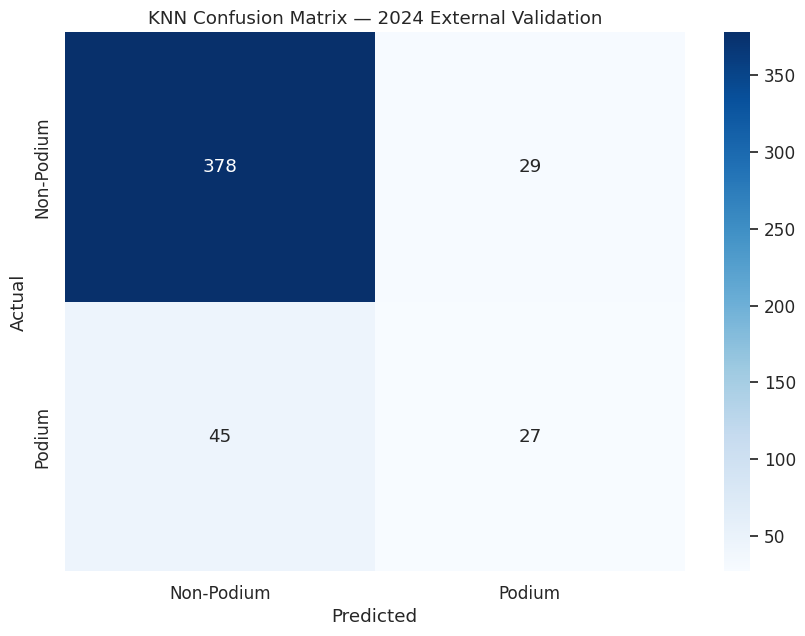

In [47]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make predictions on test set
y_pred_test = knn.predict(X_test_scaled)
print("--- KNN: 80/20 Test Set Classification Report (2019-2023) ---")
print(classification_report(y_test, y_pred_test))

# Make predictions on 2024 validation set
y_pred_2024 = knn.predict(X_2024_scaled)
print("--- KNN: External Validation (2024) Classification Report ---")
print(classification_report(y_2024, y_pred_2024))

# Create confusion matrix
conf_matrix = confusion_matrix(y_2024, y_pred_2024)
plt.figure(figsize=(10, 7))
# Plot confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Podium', 'Podium'],
            yticklabels=['Non-Podium', 'Podium'])
plt.title('KNN Confusion Matrix — 2024 External Validation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### Logistic Regression


--- Logistic Regression: 80/20 Test Set Classification Report (2019-2023) ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       354
           1       0.70      0.63      0.66        62

    accuracy                           0.90       416
   macro avg       0.82      0.79      0.80       416
weighted avg       0.90      0.90      0.90       416

--- Logistic Regression: External Validation (2024) Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       407
           1       0.52      0.40      0.45        72

    accuracy                           0.85       479
   macro avg       0.71      0.67      0.68       479
weighted avg       0.84      0.85      0.85       479



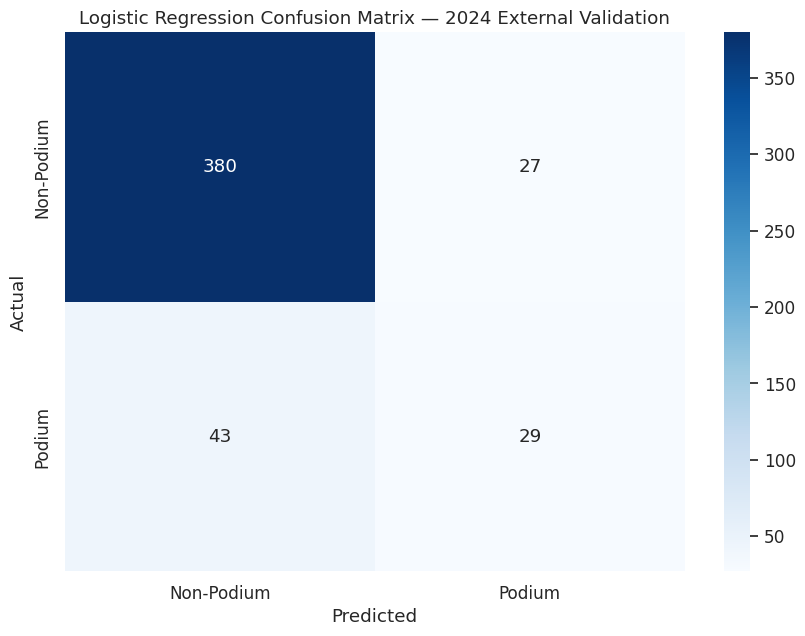

In [48]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Make predictions on test set
y_pred_test = log_reg.predict(X_test_scaled)
print("--- Logistic Regression: 80/20 Test Set Classification Report (2019-2023) ---")
print(classification_report(y_test, y_pred_test))

# Make predictions on 2024 validation set
y_pred_2024 = log_reg.predict(X_2024_scaled)
print("--- Logistic Regression: External Validation (2024) Classification Report ---")
print(classification_report(y_2024, y_pred_2024))

# Create confusion matrix
conf_matrix = confusion_matrix(y_2024, y_pred_2024)
plt.figure(figsize=(10, 7))
# Plot confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Podium', 'Podium'],
            yticklabels=['Non-Podium', 'Podium'])
plt.title('Logistic Regression Confusion Matrix — 2024 External Validation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### XGBoost


--- XGBoost: 80/20 Test Set Classification Report (2019-2023) ---
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       354
           1       0.67      0.65      0.66        62

    accuracy                           0.90       416
   macro avg       0.80      0.79      0.80       416
weighted avg       0.90      0.90      0.90       416

--- XGBoost: External Validation (2024) Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       407
           1       0.64      0.51      0.57        72

    accuracy                           0.88       479
   macro avg       0.78      0.73      0.75       479
weighted avg       0.87      0.88      0.88       479



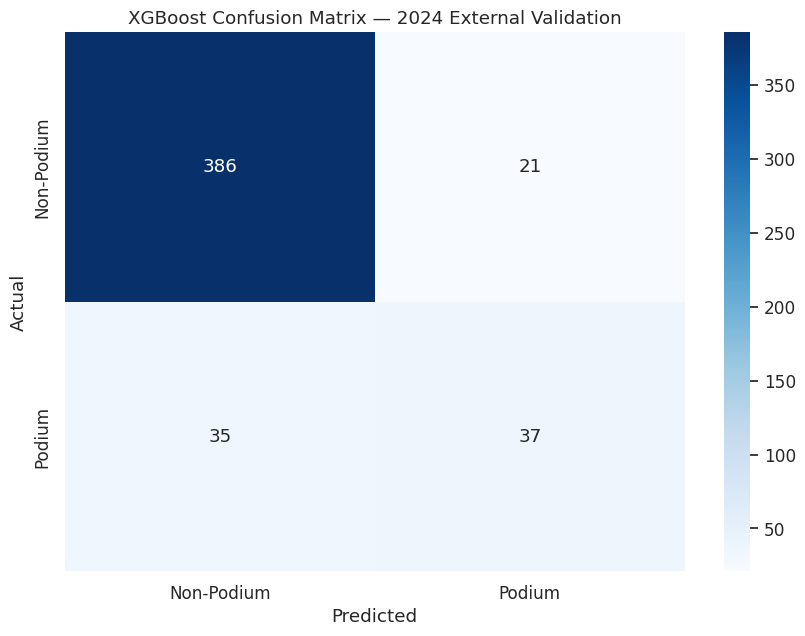

In [49]:
from xgboost import XGBClassifier

# Initialize XGBoost classifier
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                    random_state=42, eval_metric='logloss')
# Fit the model
xgb.fit(X_train, y_train)

# Make predictions on test set
y_pred_test = xgb.predict(X_test)
print("--- XGBoost: 80/20 Test Set Classification Report (2019-2023) ---")
print(classification_report(y_test, y_pred_test))

# Make predictions on 2024 validation set
y_pred_2024 = xgb.predict(X_2024)
print("--- XGBoost: External Validation (2024) Classification Report ---")
print(classification_report(y_2024, y_pred_2024))

# Create confusion matrix
conf_matrix = confusion_matrix(y_2024, y_pred_2024)
plt.figure(figsize=(10, 7))
# Plot confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Podium', 'Podium'],
            yticklabels=['Non-Podium', 'Podium'])
plt.title('XGBoost Confusion Matrix — 2024 External Validation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### Hyperparameter tuning 

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.9}
--- Best Model: 80/20 Test Set Classification Report (2019-2023) ---
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       354
           1       0.66      0.61      0.63        62

    accuracy                           0.89       416
   macro avg       0.79      0.78      0.79       416
weighted avg       0.89      0.89      0.89       416



<Axes: >

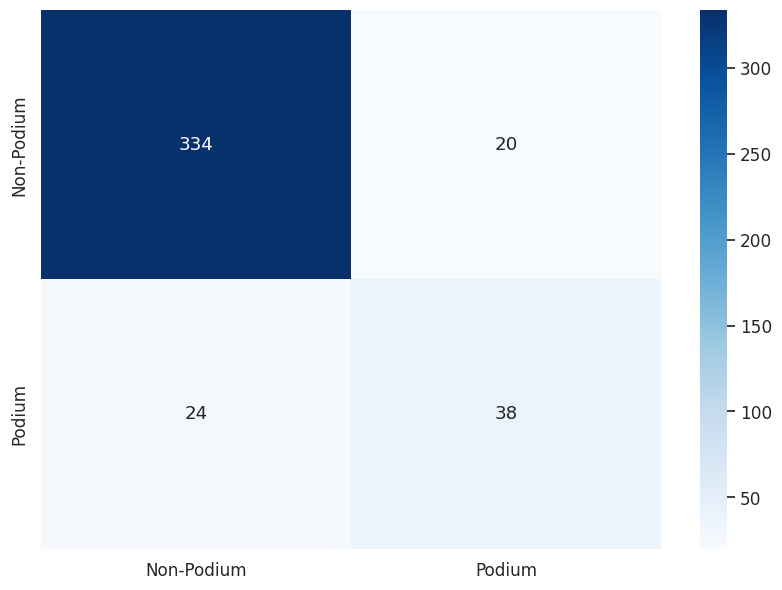

In [ ]:
### Grid Search
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Initialize XGBoost classifier (separate name so baseline `xgb` stays fitted)
xgb_grid = XGBClassifier(random_state=42, eval_metric='logloss')

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_grid,
    param_grid=param_grid,
    # use the f1 score as the scoring metric
    scoring='f1',
    # use 5-fold cross validation
    cv=5,
    verbose=1,
    # use all available CPU cores
    n_jobs=-1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Get best parameters
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Evaluate best model
best_model = grid_search.best_estimator_

# Display classification report
y_pred_test = best_model.predict(X_test)
print("--- Best Model: 80/20 Test Set Classification Report (2019-2023) ---")
print(classification_report(y_test, y_pred_test))

# Create confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 7))
# Plot confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Podium', 'Podium'],
            yticklabels=['Non-Podium', 'Podium'])


In [63]:
### Apply best model parameters to XGBoost
xgb_best = XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
xgb_best.fit(X_train, y_train)

# Make predictions on test set
y_pred_test = xgb_best.predict(X_test)
print("--- Best Model: 80/20 Test Set Classification Report (2019-2023) ---")
print(classification_report(y_test, y_pred_test))

--- Best Model: 80/20 Test Set Classification Report (2019-2023) ---
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       354
           1       0.66      0.61      0.63        62

    accuracy                           0.89       416
   macro avg       0.79      0.78      0.79       416
weighted avg       0.89      0.89      0.89       416



#### Model Comparison


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate model performance
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
    }

# Store results
results = []

# Use tuned XGBoost when grid search was run; otherwise use baseline `xgb`
if 'xgb_best' in globals():
    xgb_compare = xgb_best
    xgb_name = 'XGBoost (Tuned)'
elif 'grid_search' in globals():
    xgb_compare = grid_search.best_estimator_
    xgb_name = 'XGBoost (Tuned)'
else:
    xgb_compare = xgb
    xgb_name = 'XGBoost'

models_to_compare = [
    ('KNN', knn, X_test_scaled, X_2024_scaled),
    ('Logistic Regression', log_reg, X_test_scaled, X_2024_scaled),
    (xgb_name, xgb_compare, X_test, X_2024),
]

for name, model, X_te, X_ext in models_to_compare:
    results.append(evaluate_model(f'{name} (Test)', y_test, model.predict(X_te)))
    results.append(evaluate_model(f'{name} (2024)', y_2024, model.predict(X_ext)))

# Store results in a dataframe
comparison_df = pd.DataFrame(results)
# Round results to 3 decimal places
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1']] = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1']].round(3)
# Display comparison
comparison_df


,Model,Accuracy,Precision,Recall,F1
0,KNN (Test),0.894,0.688,0.532,0.600
1,KNN (2024),0.846,0.482,0.375,0.422
2,Logistic Regression (Test),0.904,0.696,0.629,0.661
3,Logistic Regression (2024),0.854,0.518,0.403,0.453
4,XGBoost (Tuned) (Test),0.894,0.655,0.613,0.633
5,XGBoost (Tuned) (2024),0.889,0.656,0.556,0.602


                 Model   ROC-AUC
0                  KNN  0.712650
1  Logistic Regression  0.896704
2      XGBoost (Tuned)  0.920745


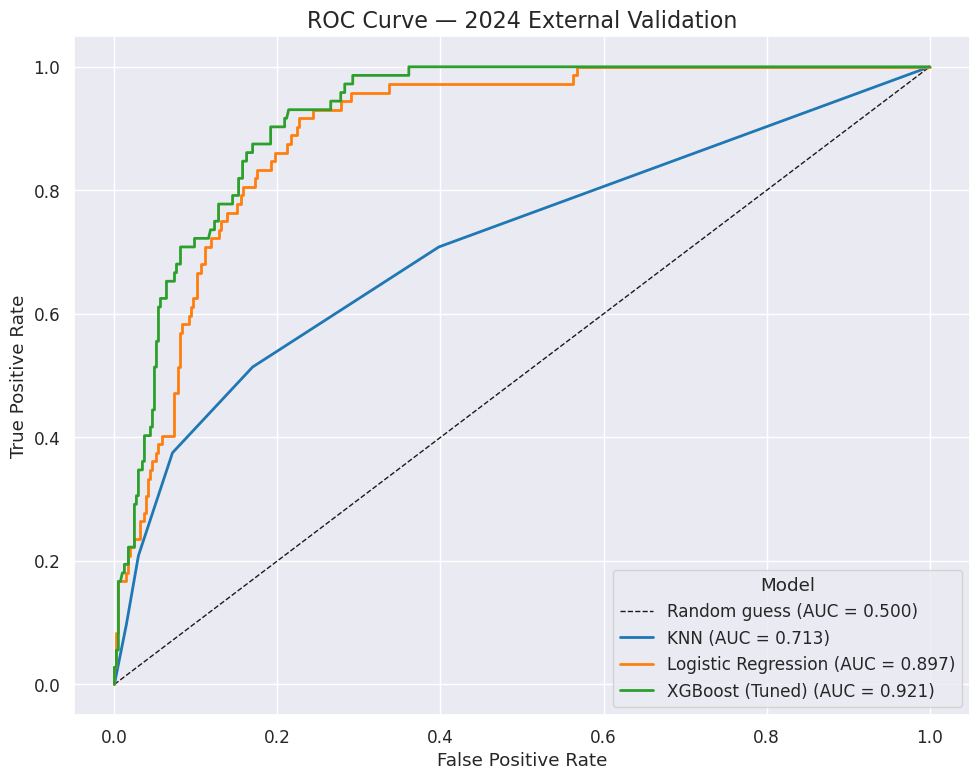

In [65]:
### ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC-AUC scores on 2024 holdout
roc_auc_scores = {}
for name, model, X_te, X_ext in models_to_compare:
    y_pred_proba = model.predict_proba(X_ext)[:, 1]
    roc_auc_scores[name] = roc_auc_score(y_2024, y_pred_proba)

# Plot ROC curves with a color-coded legend
plt.figure(figsize=(10, 8))
# Define model colors
model_colors = {
    'KNN': '#1f77b4',
    'Logistic Regression': '#ff7f0e',
    'XGBoost (Tuned)': '#2ca02c',
    'XGBoost': '#2ca02c',
}

# Plot random guess line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess (AUC = 0.500)')

# Plot ROC curve for each model
for name, model, X_te, X_ext in models_to_compare:
    y_pred_proba = model.predict_proba(X_ext)[:, 1]
    fpr, tpr, _ = roc_curve(y_2024, y_pred_proba)
    plt.plot(
        fpr,
        tpr,
        color=model_colors.get(name),
        linewidth=2,
        label=f'{name} (AUC = {roc_auc_scores[name]:.3f})',
    )

# ROC-AUC table
roc_auc_table = pd.DataFrame({
    'Model': [name for name, _, _, _ in models_to_compare],
    'ROC-AUC': [roc_auc_scores[name] for name, _, _, _ in models_to_compare]
})
# Display table
print(roc_auc_table)

# Add title and labels
plt.title('ROC Curve — 2024 External Validation', fontsize=16)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Legend displayed in lower right corner
plt.legend(title='Model', loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


### Summary

- The ROC-AUC curve shows how well the classification models separate podium finishes from non-podium finishes on the 2024 external validation set. A random classifier would have an AUC of 0.500.

    - The top overall performer was the tuned XGBoost model with a 92.1% AUC score.
    - The second-best performer was Logistic Regression with an 89.7% AUC score.
    - KNN was the weakest model with a 71.3% AUC score.

The classification report separates performance by class, where class 0 represents non-podium finishes and class 1 represents podium finishes (1st, 2nd, or 3rd place). Because podium finishes are the target outcome and minority class, the class 1 F1 score is the most relevant metric for this analysis.

- Options to potentially improve performance include adding race-day variables/features such as tire choice, pit strategy, weather, penalties, safety cars, or mechanical failures.